# D11 · People, runs, visits, and hierarchical uncertainty

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PD02](../../curriculum/papers/design.md#pd02), [PD06](../../curriculum/papers/design.md#pd06).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** Why does adding visits not automatically add independent people or separate within-person change?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

A first-level model estimates a participant's task contrast from their scans. A second-level model uses participant-level contrasts to ask about a population. These levels have different units and noise sources. Pooling thousands of scans from several people into one ordinary group test treats repeated measurements as new independent people and can make the reported precision absurdly high.

The elementary hierarchy below has a true mean, a person-specific deviation, and run-level noise. Averaging more runs reduces run noise in each person's summary, but does not remove stable between-person variation. Adding independently sampled people addresses population uncertainty. With unequal within-person precision, weighted or mixed-effects models may be appropriate; equal-person summaries are a transparent baseline for the equally weighted person-level estimand, not a universal optimum.

We separately demonstrate pairing. Two visits share a person's stable baseline. Subtracting the same person's first visit from the second can cancel that baseline and reduce uncertainty of change. Subtracting one person's before value from another's after value destroys the relevant covariance. The marginal before and after means can remain unchanged, so a mean-only audit misses the mistake. Pair IDs, not row order, establish the matching.

Hierarchical modelling also allows partial pooling: noisy individual estimates can be pulled toward a population distribution. The amount of shrinkage depends on within-person uncertainty and between-person variation. We use known variances for an exact normal-normal illustration. These weights are not permission to shrink everything toward zero or to call the shrunk estimate the original observation. They represent a model-based estimate with specific assumptions. Real multilevel analyses may require random slopes, family or site clusters, heteroscedasticity, and model diagnostics. Population inference is not obtained simply by appending a participant-ID column to any arbitrary regression.

Keep person and run axes visible. Compare the naive row SE with the SE of independent person summaries.

People / rows: 40 480 SE person / naive: 0.2769686181886379 0.08198669856882145


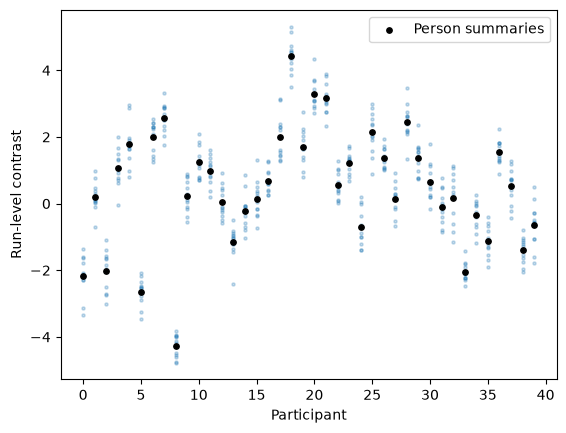

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng=np.random.default_rng(211)
people,runs=40,12
person_effect=rng.normal(0,2,people)
y=.5+person_effect[:,None]+rng.normal(0,.5,size=(people,runs))
summary=y.mean(axis=1)
se_people=summary.std(ddof=1)/np.sqrt(people)
se_naive=y.ravel().std(ddof=1)/np.sqrt(y.size)
assert se_people>2*se_naive
assert np.isclose(y.mean(),summary.mean())
print('People / rows:',people,y.size,'SE person / naive:',se_people,se_naive)
plt.scatter(np.repeat(np.arange(people),runs),y.ravel(),s=5,alpha=.25)
plt.scatter(np.arange(people),summary,color='black',s=15,label='Person summaries')
plt.xlabel('Participant');plt.ylabel('Run-level contrast');plt.legend();plt.show()

Pairing preserves individual identity; partial pooling uses uncertainty, not arbitrary smoothing.

In [2]:
before=np.array([-5.,0.,5.,10.])
after=before+np.array([.8,1.2,.9,1.1])
paired=after-before; broken=after[::-1]-before
assert np.isclose(paired.mean(),broken.mean())
assert broken.std(ddof=1)>20*paired.std(ddof=1)
individual=np.array([2.,2.]); within_var=np.array([.1,4.])
population_mean=0.; between_var=1.
weight=between_var/(between_var+within_var)
shrunk=weight*individual+(1-weight)*population_mean
assert shrunk[0]>shrunk[1]
assert np.allclose(shrunk,[20/11,.4])
print('Observed / reliability weights / shrunk:',individual,weight,shrunk)

Observed / reliability weights / shrunk: [2. 2.] [0.90909091 0.2       ] [1.81818182 0.4       ]


## Supervise the AI, then transfer the idea

**AI prompt:** “Name the independent population-sampling unit and both variance components. Explain why repeated runs narrow a person's estimate but do not create new people. Check pair IDs before differences. Explain the known-variance shrinkage formula without claiming it estimates variances from our tiny example.”

**Deliberate mistake:** report n=480 participants for 40 people with 12 runs. Repair the sample description and inference. Then reverse after-values and explain why unchanged average change is insufficient validation. Transfer by saving first-level contrast estimates and their uncertainties, tracking visits and families, and stating whether the target is a fixed set of people or a broader population. Deliver a hierarchy diagram and a planned group model, including which covariance terms or clustering assumptions an expert must review.

## Answer key — read after your own explanation

Both averaging methods give the same grand mean with equal run counts, but the naive row SE is too small because runs share people. Incorrect pairing preserves the mean difference and inflates its variance in this example. A person estimate with variance four shrinks more than one with variance .1 under the specified prior. This known-variance illustration does not fit a complete mixed-effects model or validate arbitrary shrinkage.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [DartBrains Group Analysis, hierarchical and mixed-effects sections](https://github.com/ljchang/dartbrains/blob/b72537ad25deee0281248a415a052cd87ff325de/content/Group_Analysis.ipynb); [FSL common GLM design patterns](https://fsl.fmrib.ox.ac.uk/fsl/docs/statistics/glm.html); [Lazic pseudoreplication paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC2817684/). See [the coverage and gaps](../../curriculum/design_coverage.md).

### Return to the research question

Reopen [PD02](../../curriculum/papers/design.md#pd02), [PD06](../../curriculum/papers/design.md#pd06) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
